In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
sns.set_style('darkgrid')

In [4]:
df = pd.read_excel('../data/Suspension Data Labeling.xlsx', sheet_name='Test_Labels')

# # удаляем лишние строки
df = df.iloc[2:-5]

In [5]:
df.head()

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments
2,2.0,1,many,0,0,0,0,0,2,NaN
3,3.0,1,many,0,0,0,0,0,1,NaN
4,4.0,1,many,0,0,0,0,0,1,NaN
5,5.0,1,many,0,0,0,0,0,1,C+
6,6.0,1,many,0,0,0,0,0,1,NaN


# Противоречащие здравому смыслу сочетания признаков

In [6]:
dict_errors = {
    1: 'Drop tests without video',
    2: '0 – Receding / 1 – Rebound',
    3: '0 – Receding / 1 or 2 – Rim merging',
    4: '0 – Receding / 1 or 2 – Rebound',
    5: '0 – Receding / 1 or more – Number of detached small droplets during Receding…',
    6: '0 – Receding / 1 or more – Number of detached droplets during Rebound',
    7: '2 – Receding / 0 – Number of detached small droplets during Receding…',
    8: '0 or 1 – Rim merging / 1 or 2 – Rebound'
}

In [7]:
broken_indexes = {}

## Drop tests without video

In [8]:
df_temp_broken = df[df['Comments']=='Видео отсутствует']
df_temp_broken

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments
9,9.0,-,-,-,-,-,-,-,1,Видео отсутствует
31,31.0,-,-,-,-,-,-,-,1,Видео отсутствует
49,49.0,-,-,-,-,-,-,-,1,Видео отсутствует
277,277.0,1,0,1,1,0,0,0,1,Видео отсутствует


In [9]:
broken_indexes[1] = list(df_temp_broken.index)

## 0 – Receding / 1 – Rebound

In [10]:
df_temp_broken = df[
    (df['Droplet Receding']==0) & 
    (df['Rebound']==1)
].copy()
df_temp_broken.shape

(6, 10)

In [11]:
broken_indexes[2] = list(df_temp_broken.index)

## 0 – Receding / 1 or 2 – Rim merging

In [12]:
df_temp_broken = df[
    (df['Droplet Receding']==0) & 
    (
     (df['Rim merging or Central jet ejecting']==1) | 
     (df['Rim merging or Central jet ejecting']==2)
    )
].copy()
df_temp_broken.shape

(18, 10)

In [13]:
broken_indexes[3] = list(df_temp_broken.index)

## 0 – Receding / 1 or 2 – Rebound

In [14]:
df_temp_broken = df[
    (df['Droplet Receding']==0) & 
    (
     (df['Rebound']==1) | 
     (df['Rebound']==2)
    )
].copy()
df_temp_broken.shape

(8, 10)

In [15]:
broken_indexes[4] = list(df_temp_broken.index)

## 0 – Receding / 1 or more – Number of detached small droplets during Receding…

In [16]:
df['Number of detached small droplets during Receding or Rim merging'].unique()

array([0, '-', 'many', 4, 3, 2, 1, nan], dtype=object)

In [17]:
df_temp_broken = df[
    (df['Droplet Receding']==0) &
    (df['Number of detached small droplets during Receding or Rim merging'].isin([1, 2, 3, 4]))
].copy()
df_temp_broken.shape

(2, 10)

In [18]:
broken_indexes[5] = list(df_temp_broken.index)

## 0 – Receding / 1 or more – Number of detached droplets during Rebound

In [19]:
df['Number of detached droplets during Rebound'].unique()

array([0, '-', 1, 3, 2], dtype=object)

In [20]:
df_temp_broken = df[
    (df['Droplet Receding']==0) &
    (df['Number of detached droplets during Rebound'].isin([1, 2, 3]))
].copy()
df_temp_broken.shape

(0, 10)

In [21]:
broken_indexes[6] = list(df_temp_broken.index)

## 2 – Receding / 0 – Number of detached small droplets during Receding…

In [22]:
df_temp_broken = df[
    (df['Droplet Receding']==2) &
    (df['Number of detached small droplets during Receding or Rim merging']==0)
].copy()
df_temp_broken.shape

(2, 10)

In [23]:
broken_indexes[7] = list(df_temp_broken.index)

## 0 or 1 – Rim merging / 1 or 2 – Rebound

In [24]:
df_temp_broken = df[
    (df['Rim merging or Central jet ejecting'].isin([0, 1])) &
    (df['Rebound'].isin([1, 2]))
].copy()
df_temp_broken.shape

(11, 10)

In [25]:
broken_indexes[8] = list(df_temp_broken.index)

## Итоговое количество "битых" наблюдений

In [26]:
all_broken = np.unique(np.hstack(broken_indexes.values()))

C:\Users\dimaz\AppData\Local\Temp\ipykernel_12800\1516608079.py:1: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  all_broken = np.unique(np.hstack(broken_indexes.values()))


In [27]:
print(f'Общее количество "битых" наблюдений: {all_broken.size}')
print(f'Процент "битых" наблюдений: {(all_broken.size / df.shape[0])*100:.4f} %')

Общее количество "битых" наблюдений: 32
Процент "битых" наблюдений: 8.1218 %


In [28]:
reversed_indexes = {}
for key, value_list in broken_indexes.items():
    if len(value_list)==0:
        continue
    for value in value_list:
        if value in reversed_indexes.keys():
            reversed_indexes[value].append(key)
        else:
            reversed_indexes[value] = [key]

In [29]:
reversed_indexes

{9: [1],
 31: [1],
 49: [1],
 277: [1],
 97: [2, 3, 4, 5, 8],
 99: [2, 3, 4],
 108: [2, 3, 4],
 139: [2, 3, 4],
 151: [2, 3, 4, 8],
 163: [2, 4, 8],
 38: [3],
 40: [3],
 41: [3, 5],
 42: [3],
 43: [3],
 65: [3],
 67: [3],
 83: [3],
 145: [3],
 165: [3],
 229: [3, 4],
 230: [3, 4],
 239: [3],
 302: [7],
 363: [7, 8],
 104: [8],
 158: [8],
 181: [8],
 298: [8],
 329: [8],
 330: [8],
 369: [8]}

In [30]:
dict_errors

{1: 'Drop tests without video',
 2: '0 – Receding / 1 – Rebound',
 3: '0 – Receding / 1 or 2 – Rim merging',
 4: '0 – Receding / 1 or 2 – Rebound',
 5: '0 – Receding / 1 or more – Number of detached small droplets during Receding…',
 6: '0 – Receding / 1 or more – Number of detached droplets during Rebound',
 7: '2 – Receding / 0 – Number of detached small droplets during Receding…',
 8: '0 or 1 – Rim merging / 1 or 2 – Rebound'}

# Анализ данныз после исправления ошибок в разметке

In [31]:
df_edit = pd.read_excel('../data/Suspension Data Labeling Edited.xlsx', sheet_name='Test_Labels')

# # удаляем лишние строки
df_edit = df_edit.iloc[2:-5]
for column in df_edit.columns:
    if 'Unnamed' in column:
        df_edit.drop(column, axis=1, inplace=True)

In [32]:
df_edit.head()

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments
2,2.0,1,many,0,0,0,0,0,2,NaN
3,3.0,1,many,0,0,0,0,0,1,NaN
4,4.0,1,many,0,0,0,0,0,1,NaN
5,5.0,1,many,0,0,0,0,0,1,C+
6,6.0,1,many,0,0,0,0,0,1,NaN


## Противоречащие здравому смыслу сочетания признаков

In [33]:
broken_indexes = {}

### Drop tests without video

In [34]:
df_temp_broken = df_edit[df_edit['Comments']=='Видео отсутствует']
df_temp_broken

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments
9,9.0,-,-,-,-,-,-,-,1,Видео отсутствует
31,31.0,-,-,-,-,-,-,-,1,Видео отсутствует
49,49.0,-,-,-,-,-,-,-,1,Видео отсутствует
277,277.0,1,0,1,1,0,0,0,1,Видео отсутствует


In [35]:
broken_indexes[1] = list(df_temp_broken.index)

### 0 – Receding / 1 – Rebound

In [36]:
df_temp_broken = df_edit[
    (df_edit['Droplet Receding']==0) & 
    (df_edit['Rebound']==1)
].copy()
df_temp_broken.shape

(0, 10)

In [37]:
broken_indexes[2] = list(df_temp_broken.index)

### 0 – Receding / 1 or 2 – Rim merging

In [38]:
df_temp_broken = df_edit[
    (df_edit['Droplet Receding']==0) & 
    (
     (df_edit['Rim merging or Central jet ejecting']==1) | 
     (df_edit['Rim merging or Central jet ejecting']==2)
    )
].copy()
df_temp_broken.shape

(0, 10)

In [39]:
broken_indexes[3] = list(df_temp_broken.index)

### 0 – Receding / 1 or 2 – Rebound

In [40]:
df_temp_broken = df_edit[
    (df_edit['Droplet Receding']==0) & 
    (
     (df_edit['Rebound']==1) | 
     (df_edit['Rebound']==2)
    )
].copy()
df_temp_broken.shape

(0, 10)

In [41]:
broken_indexes[4] = list(df_temp_broken.index)

### 0 – Receding / 1 or more – Number of detached small droplets during Receding…

In [42]:
df_edit['Number of detached small droplets during Receding or Rim merging'].unique()

array([0, '-', 'many', 4, 3, 2, 1], dtype=object)

In [43]:
df_temp_broken = df_edit[
    (df_edit['Droplet Receding']==0) &
    (df_edit['Number of detached small droplets during Receding or Rim merging'].isin([1, 2, 3, 4]))
].copy()
df_temp_broken.shape

(0, 10)

In [44]:
broken_indexes[5] = list(df_temp_broken.index)

### 0 – Receding / 1 or more – Number of detached droplets during Rebound

In [45]:
df_edit['Number of detached droplets during Rebound'].unique()

array([0, '-', 1, 3, 2], dtype=object)

In [46]:
df_temp_broken = df_edit[
    (df_edit['Droplet Receding']==0) &
    (df_edit['Number of detached droplets during Rebound'].isin([1, 2, 3]))
].copy()
df_temp_broken.shape

(0, 10)

In [47]:
broken_indexes[6] = list(df_temp_broken.index)

### 2 – Receding / 0 – Number of detached small droplets during Receding…

In [48]:
df_temp_broken = df_edit[
    (df_edit['Droplet Receding']==2) &
    (df_edit['Number of detached small droplets during Receding or Rim merging']==0)
].copy()
df_temp_broken.shape

(0, 10)

In [49]:
broken_indexes[7] = list(df_temp_broken.index)

### 0 or 1 – Rim merging / 1 or 2 – Rebound

In [50]:
df_temp_broken = df_edit[
    (df_edit['Rim merging or Central jet ejecting'].isin([0, 1])) &
    (df_edit['Rebound'].isin([1, 2]))
].copy()
df_temp_broken.shape

(0, 10)

In [51]:
broken_indexes[8] = list(df_temp_broken.index)

### Проверить аномалии для конкретных значений: Final droplets count != Total number of dropped drops + Number of detached small droplets during Spreading + Number of detached small droplets during Receding or Rim merging 

In [52]:
df_edit['Final droplets count'].unique()

array([2, 1, 7, 6, 5, 'many', 0, 3, 4], dtype=object)

In [53]:
df_edit['Total number of dropped drops'].unique()

array([1, 2, '-', 3, 4, nan], dtype=object)

In [54]:
df_edit['Number of detached small droplets during Spreading'].unique()

array(['many', '-', 4, 1, 0, 2, 5, 3, 7], dtype=object)

In [55]:
df_edit['Number of detached small droplets during Receding or Rim merging'].unique()

array([0, '-', 'many', 4, 3, 2, 1], dtype=object)

In [56]:
df_temp = df_edit.copy()
df_temp['sum'] = ''
for index, row in df_temp.iterrows():
    if (
        (type(row['Total number of dropped drops']) == int) &
        (type(row['Number of detached small droplets during Spreading']) == int) &
        (type(row['Number of detached small droplets during Receding or Rim merging']) == int) 
    ):
        df_temp.loc[index, 'sum'] = row['Total number of dropped drops'] + row['Number of detached small droplets during Spreading'] + row['Number of detached small droplets during Receding or Rim merging']
    if (
        (row['Total number of dropped drops'] == '-') |
        (row['Number of detached small droplets during Spreading'] == '-') |
        (row['Number of detached small droplets during Receding or Rim merging'] == '-') 
    ):
        df_temp.loc[index, 'sum'] = '-'
    
    if (
        (row['Total number of dropped drops'] == 'many') |
        (row['Number of detached small droplets during Spreading'] == 'many') |
        (row['Number of detached small droplets during Receding or Rim merging'] == 'many') 
    ):
        df_temp.loc[index, 'sum'] = 'many'
    if (
        pd.isnull(row['Total number of dropped drops']) |
        pd.isnull(row['Number of detached small droplets during Spreading']) |
        pd.isnull(row['Number of detached small droplets during Receding or Rim merging'])
    ):
        df_temp.loc[index, 'sum'] = ''

In [57]:
df_temp.shape

(394, 11)

In [58]:
df_temp[df_temp['sum']!=df_temp['Final droplets count']].shape

(185, 11)

In [59]:
mask = df_temp['sum'].apply(lambda x: type(x) == int)
df_temp[
    (df_temp['sum']==df_temp['Final droplets count']) &
    mask
].shape

(124, 11)

In [60]:
pd.DataFrame(df_temp[df_temp['sum']!=df_temp['Final droplets count']].groupby(
    ['sum', 'Final droplets count']
).count().iloc[:, 0])

Test #
sum  Final droplets count        
1    0                          6
2    0                          3
     1                         32
3    1                          6
     2                          4
4    1                          6
     2                          2
     3                          3
     5                          1
5    1                          2
     2                          2
     4                          1
6    1                          1
     2                          1
     3                          1
     4                          1
7    1                          1
     4                          1
8    many                       1
     1                          1
-    1                          3
many 0                          3
     1                         80
     2                          7
     3                          8
     4                          2
     5                          3
     6                          2
     7                          1

In [61]:
# капли отскакивают и улетают за пределы подложки
df_temp[
    (df_temp['sum']==1) & 
    (df_temp['Final droplets count']==0)
]

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,sum
308,308.0,1,0,1,2,0,2,2,0,NaN,1
321,321.0,1,0,1,2,0,2,0,0,NaN,1
329,329.0,1,0,1,2,0,2,0,0,NaN,1
334,334.0,1,0,1,2,0,2,3,0,NaN,1
340,340.0,1,0,1,2,0,2,1,0,NaN,1
395,395.0,1,0,1,2,0,2,0,0,NaN,1


In [62]:
# Number of detached small droplets during Receding or Rim merging == 2
df_temp[
    (df_temp['sum']==2) & 
    (df_temp['Final droplets count']==3)
]

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,sum


In [63]:
# # исправление
# df_temp[
#     (df_temp['sum']==2) & 
#     (df_temp['Final droplets count']==3),
#     'Number of detached small droplets during Receding or Rim merging'
# ] = 2

In [64]:
# капли вылетают за пределы экрана, нет ошибки
df_temp[
    (df_temp['sum']==3) & 
    (df_temp['Final droplets count']==1)
]

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,sum
26,26.0,1,2,0,0,0,0,0,1,NaN,3
76,76.0,1,2,1,2,0,1,0,1,NaN,3
125,125.0,1,2,0,0,0,0,0,1,NaN,3
172,172.0,1,2,1,1,0,0,0,1,NaN,3
281,281.0,1,2,1,2,0,0,0,1,NaN,3
355,355.0,1,2,1,1,0,0,0,1,NaN,3


In [65]:
# вылет за пределы камеры, падение маленькой капли в основную
df_temp[
    (df_temp['sum']==4) & 
    (df_temp['Final droplets count']==1)
]

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,sum
51,51.0,2,2,0,0,0,0,0,1,NaN,4
100,100.0,1,3,1,1,0,0,0,1,NaN,4
118,118.0,1,3,0,0,0,0,0,1,NaN,4
119,119.0,1,3,0,0,0,0,0,1,NaN,4
150,150.0,1,3,1,1,0,0,0,1,NaN,4
392,392.0,1,3,1,1,0,0,0,1,NaN,4


In [66]:
# ошибка разметки: Final droplets count == 3
# "аномалия" при изменении сохранится, маленькая капля попала в основную
df_temp[
    (df_temp['sum']==4) & 
    (df_temp['Final droplets count']==5)
]

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,sum
146,146.0,1,3,0,0,0,0,0,5,NaN,4


In [67]:
# 165 - ошибка разметки: Final droplets count == 3
# 165 - ошибка разметки: Final droplets count == 2, остальное
# улетело из кадра
df_temp[
    (df_temp['sum']==5) & 
    (df_temp['Final droplets count']==1)
]

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,sum
165,165.0,1,4,1,1,0,0,0,1,NaN,5
207,207.0,1,4,1,0,0,0,0,1,NaN,5


In [68]:
# ошибка разметки: Final droplets count == 3
# остальное улетело из кадра
# "аномалия" при изменении сохранится
df_temp[
    (df_temp['sum']==6) & 
    (df_temp['Final droplets count']==1)
]

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,sum
220,220.0,1,5,0,0,0,0,0,1,NaN,6


In [69]:
# ошибка разметки: Final droplets count == 2
# остальные капли улетели за пределы экрана
df_temp[
    (df_temp['sum']==7) & 
    (df_temp['Final droplets count']==1)
]

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,sum
27,27.0,2,5,0,0,0,0,0,1,NaN,7


In [70]:
# ??? Ошибка пандаса
df_temp[
    (df_temp['sum']==8) & 
    (df_temp['Final droplets count']==1)
]

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,sum


In [71]:
df_temp[
    (df_temp['sum']=='many') & 
    (df_temp['Final droplets count']==1)
].sample(20).sort_index()

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,sum
5,5.0,1,many,0,0,0,0,0,1,C+,many
6,6.0,1,many,0,0,0,0,0,1,NaN,many
24,24.0,1,many,0,0,0,0,0,1,NaN,many
38,38.0,1,many,1,1,0,0,0,1,NaN,many
127,127.0,1,many,0,0,0,0,0,1,NaN,many
130,130.0,1,many,0,0,0,0,0,1,NaN,many
138,138.0,1,many,0,0,0,0,0,1,NaN,many
152,152.0,1,many,0,0,0,0,0,1,NaN,many
171,171.0,1,many,1,1,0,0,0,1,NaN,many
189,189.0,1,many,0,0,0,0,0,1,NaN,many


In [72]:
# 202 - вытянутые сгустки  отдельно от капли
# 343 - ошибка разметки, Fin dr count = 2
df_temp[
    (df_temp['sum']==2) &
    (df_temp['Final droplets count']==1) &
    (df_temp['Total number of dropped drops']==1)
]

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,sum
59,59.0,1,1,1,1,0,0,0,1,NaN,2
60,60.0,1,1,1,0,0,0,0,1,NaN,2
67,67.0,1,1,1,1,0,0,0,1,NaN,2
70,70.0,1,0,1,2,1,1,0,1,NaN,2
74,74.0,1,1,0,0,0,0,0,1,NaN,2
109,109.0,1,1,1,1,0,0,0,1,NaN,2
202,202.0,1,1,1,1,0,0,0,1,NaN,2
274,274.0,1,1,1,2,0,1,0,1,NaN,2
298,298.0,1,1,1,2,0,1,1,1,NaN,2
343,343.0,1,1,1,1,0,0,0,1,NaN,2


In [73]:
pd.DataFrame(df_temp[df_temp['sum']!=df_temp['Final droplets count']].groupby(
    ['sum', 'Final droplets count']
).count().iloc[:, 0]).to_excel('grouped_sum_fdc.xlsx')

Формирование признака horizontal sum

In [74]:
df_edit['horizontal_sum'] = df_temp['sum']

In [75]:
df_edit['horizontal_sum'].unique()

array(['many', '-', 2, 3, 7, 1, 4, 6, 5, 8, ''], dtype=object)

Преобразования аналогичные final_total_count_binary

In [76]:
df_edit.loc[
    df_edit['horizontal_sum'].isin([6, 7 ,8]),
    'horizontal_sum'
] = 'many'
df_edit.loc[
    df_edit['horizontal_sum'].isin([2,3,4,5]),
    'horizontal_sum'
] = 'few'

df_edit['horizontal_sum_binary'] =0
df_edit.loc[
    df_edit['horizontal_sum']==1, 
    'horizontal_sum_binary'
] = 1

In [77]:
df_plot = df_edit[df_edit['horizontal_sum_binary']==0].copy()
df_plot.drop(columns=['Test #', 'Comments', 'horizontal_sum_binary'], inplace=True)

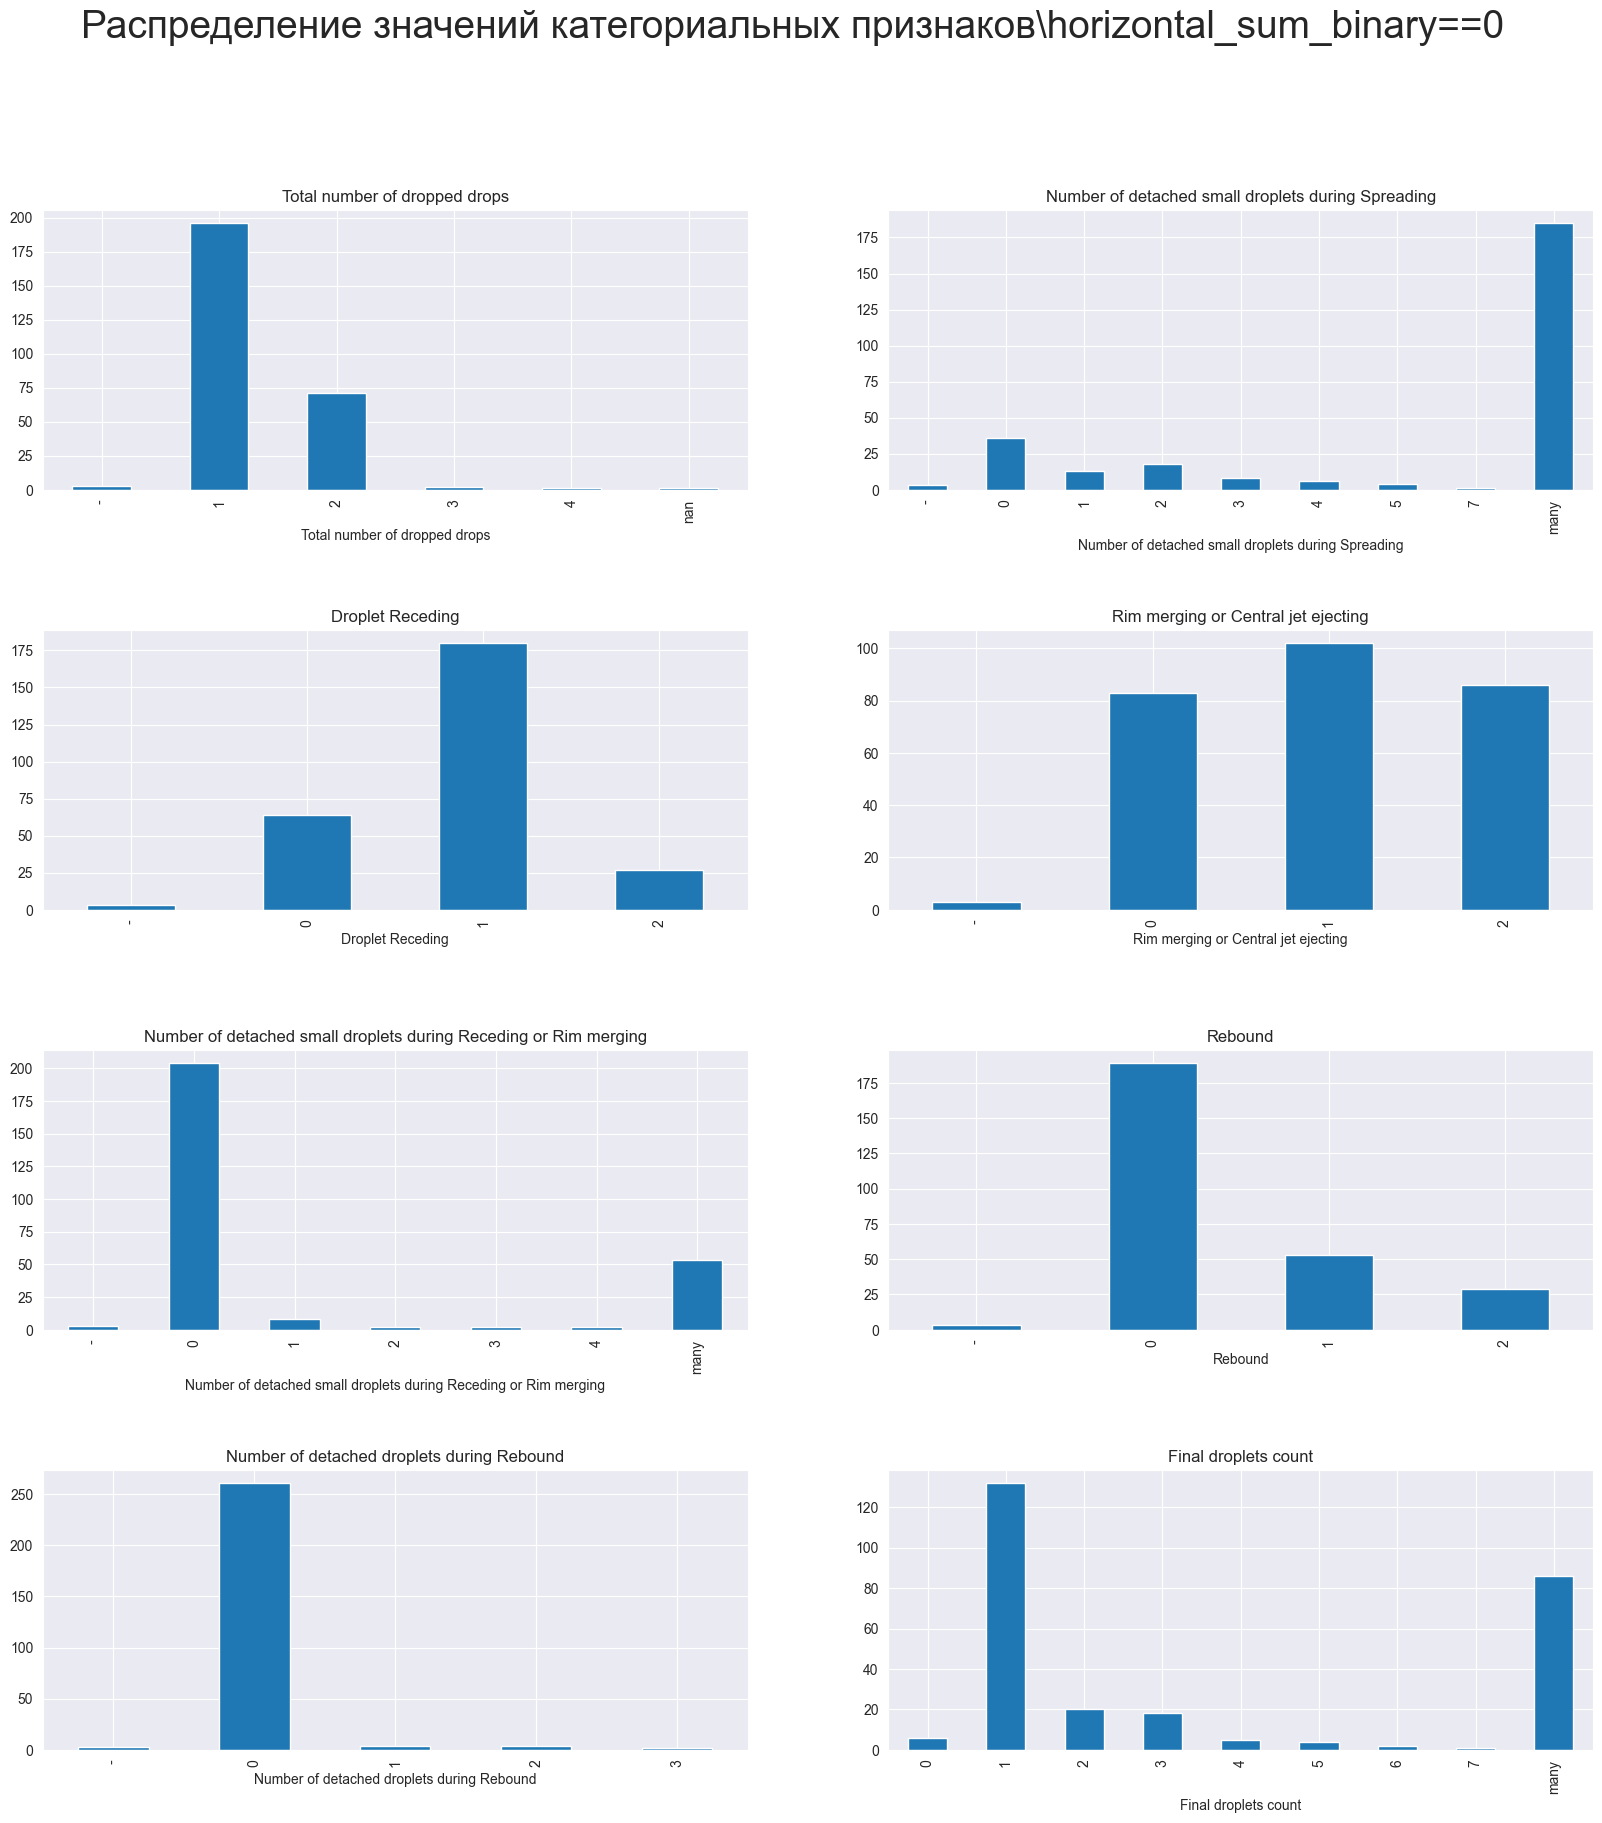

In [78]:
fig, axs = plt.subplots(4, 2, figsize=(20, 20))
plt.subplots_adjust(hspace=0.5)
fig.suptitle('Распределение значений категориальных признаков\horizontal_sum_binary==0', fontsize=28)
for column, ax in zip(df_plot.columns, axs.ravel()):
    df_plot[column] = df_plot[column].astype(str)
    df_grouped = df_plot.groupby(by=column).size()
    df_grouped.plot.bar(ax=ax)
    ax.set_title(column)
plt.show()

### Итоговое количество "битых" наблюдений

In [79]:
all_broken = np.unique(np.hstack(broken_indexes.values()))

C:\Users\dimaz\AppData\Local\Temp\ipykernel_12800\1516608079.py:1: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  all_broken = np.unique(np.hstack(broken_indexes.values()))


In [80]:
print(f'Общее количество "битых" наблюдений: {all_broken.size}')
print(f'Процент "битых" наблюдений: {(all_broken.size / df.shape[0])*100:.4f} %')

Общее количество "битых" наблюдений: 4
Процент "битых" наблюдений: 1.0152 %


In [81]:
reversed_indexes = {}
for key, value_list in broken_indexes.items():
    if len(value_list)==0:
        continue
    for value in value_list:
        if value in reversed_indexes.keys():
            reversed_indexes[value].append(key)
        else:
            reversed_indexes[value] = [key]

In [82]:
reversed_indexes

{9: [1], 31: [1], 49: [1], 277: [1]}

Остались только наблюдения без видео

# Преобразования исходных признаков

In [83]:
df_data = df_edit.copy()
df_data.drop(list(reversed_indexes.keys()), inplace=True)
# df_data.drop('Comments', axis=1, inplace=True)
# df_data.dropna(inplace=True)
df_data

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments,horizontal_sum,horizontal_sum_binary
2,2.0,1,many,0,0,0,0,0,2,NaN,many,0
3,3.0,1,many,0,0,0,0,0,1,NaN,many,0
4,4.0,1,many,0,0,0,0,0,1,NaN,many,0
5,5.0,1,many,0,0,0,0,0,1,C+,many,0
6,6.0,1,many,0,0,0,0,0,1,NaN,many,0
...,...,...,...,...,...,...,...,...,...,...,...,...
391,391.0,2,0,1,2,0,2,0,0,NaN,few,0
392,392.0,1,3,1,1,0,0,0,1,NaN,few,0
393,393.0,1,2,1,1,0,0,0,3,NaN,few,0
394,394.0,1,0,1,1,1,0,0,2,NaN,few,0


## 0. Total number of dropped drops. Binary: one droplet - 1, more than one - 0 (not clean experiment)

In [84]:
df_data['Total number of dropped drops'].unique()

array([1, 2, 3, 4, nan], dtype=object)

In [85]:
df_data.loc[df_data['Total number of dropped drops']!=1, 'Total number of dropped drops'] = 0

## 2. Number of detached during Spreading: {0, 1, 2, 3, 4, 5, many} -> {0, few, many}

In [86]:
df_data['Number of detached small droplets during Spreading'].unique()

array(['many', 4, 1, 0, 2, 5, 3, 7], dtype=object)

In [87]:
df_data.loc[
    df_data['Number of detached small droplets during Spreading'].isin([1, 2, 3, 4, 5]),
    'Number of detached small droplets during Spreading'
] = 'few'
df_data.loc[
    df_data['Number of detached small droplets during Spreading']==7,
    'Number of detached small droplets during Spreading'
] = 'many'

## 3. Rebound: {0, 1, 2} -> {0, True}

In [88]:
df_data['Rebound'].unique()

array([0, 1, 2], dtype=object)

In [89]:
df_data.loc[df_data['Rebound']!=0, 'Rebound'] = 1

## 4. Final droplets count: {(0), 2, 3, 4, 5} (-> few без 0!). Новый признак final_total_count_binary: 1 капля - label 1; 0 капель или >1 - label 0
Вывести и проанализировать таблицу для Final droplets count == 0: интересуют доли остальных признаков при отсутствии капель на подложке. Для простоты можно построить те же столбчатые диаграммы, но только для подмножества Final total count == 0

In [90]:
df_data['Final droplets count'].unique()

array([2, 1, 7, 6, 5, 'many', 0, 3, 4], dtype=object)

In [91]:
df_data.loc[
    df_data['Final droplets count'].isin([6, 7]),
    'Final droplets count'
] = 'many'
df_data.loc[
    df_data['Final droplets count'].isin([2,3,4,5]),
    'Final droplets count'
] = 'few'

df_data['final_total_count_binary'] =0
df_data.loc[
    df_data['Final droplets count']==1, 
    'final_total_count_binary'
] = 1

### Графики для предыдущего пункта

In [92]:
df_plot = df_data[df_data['final_total_count_binary']==0].copy()
df_plot.drop(columns=['Test #', 'Comments', 'final_total_count_binary'], inplace=True)

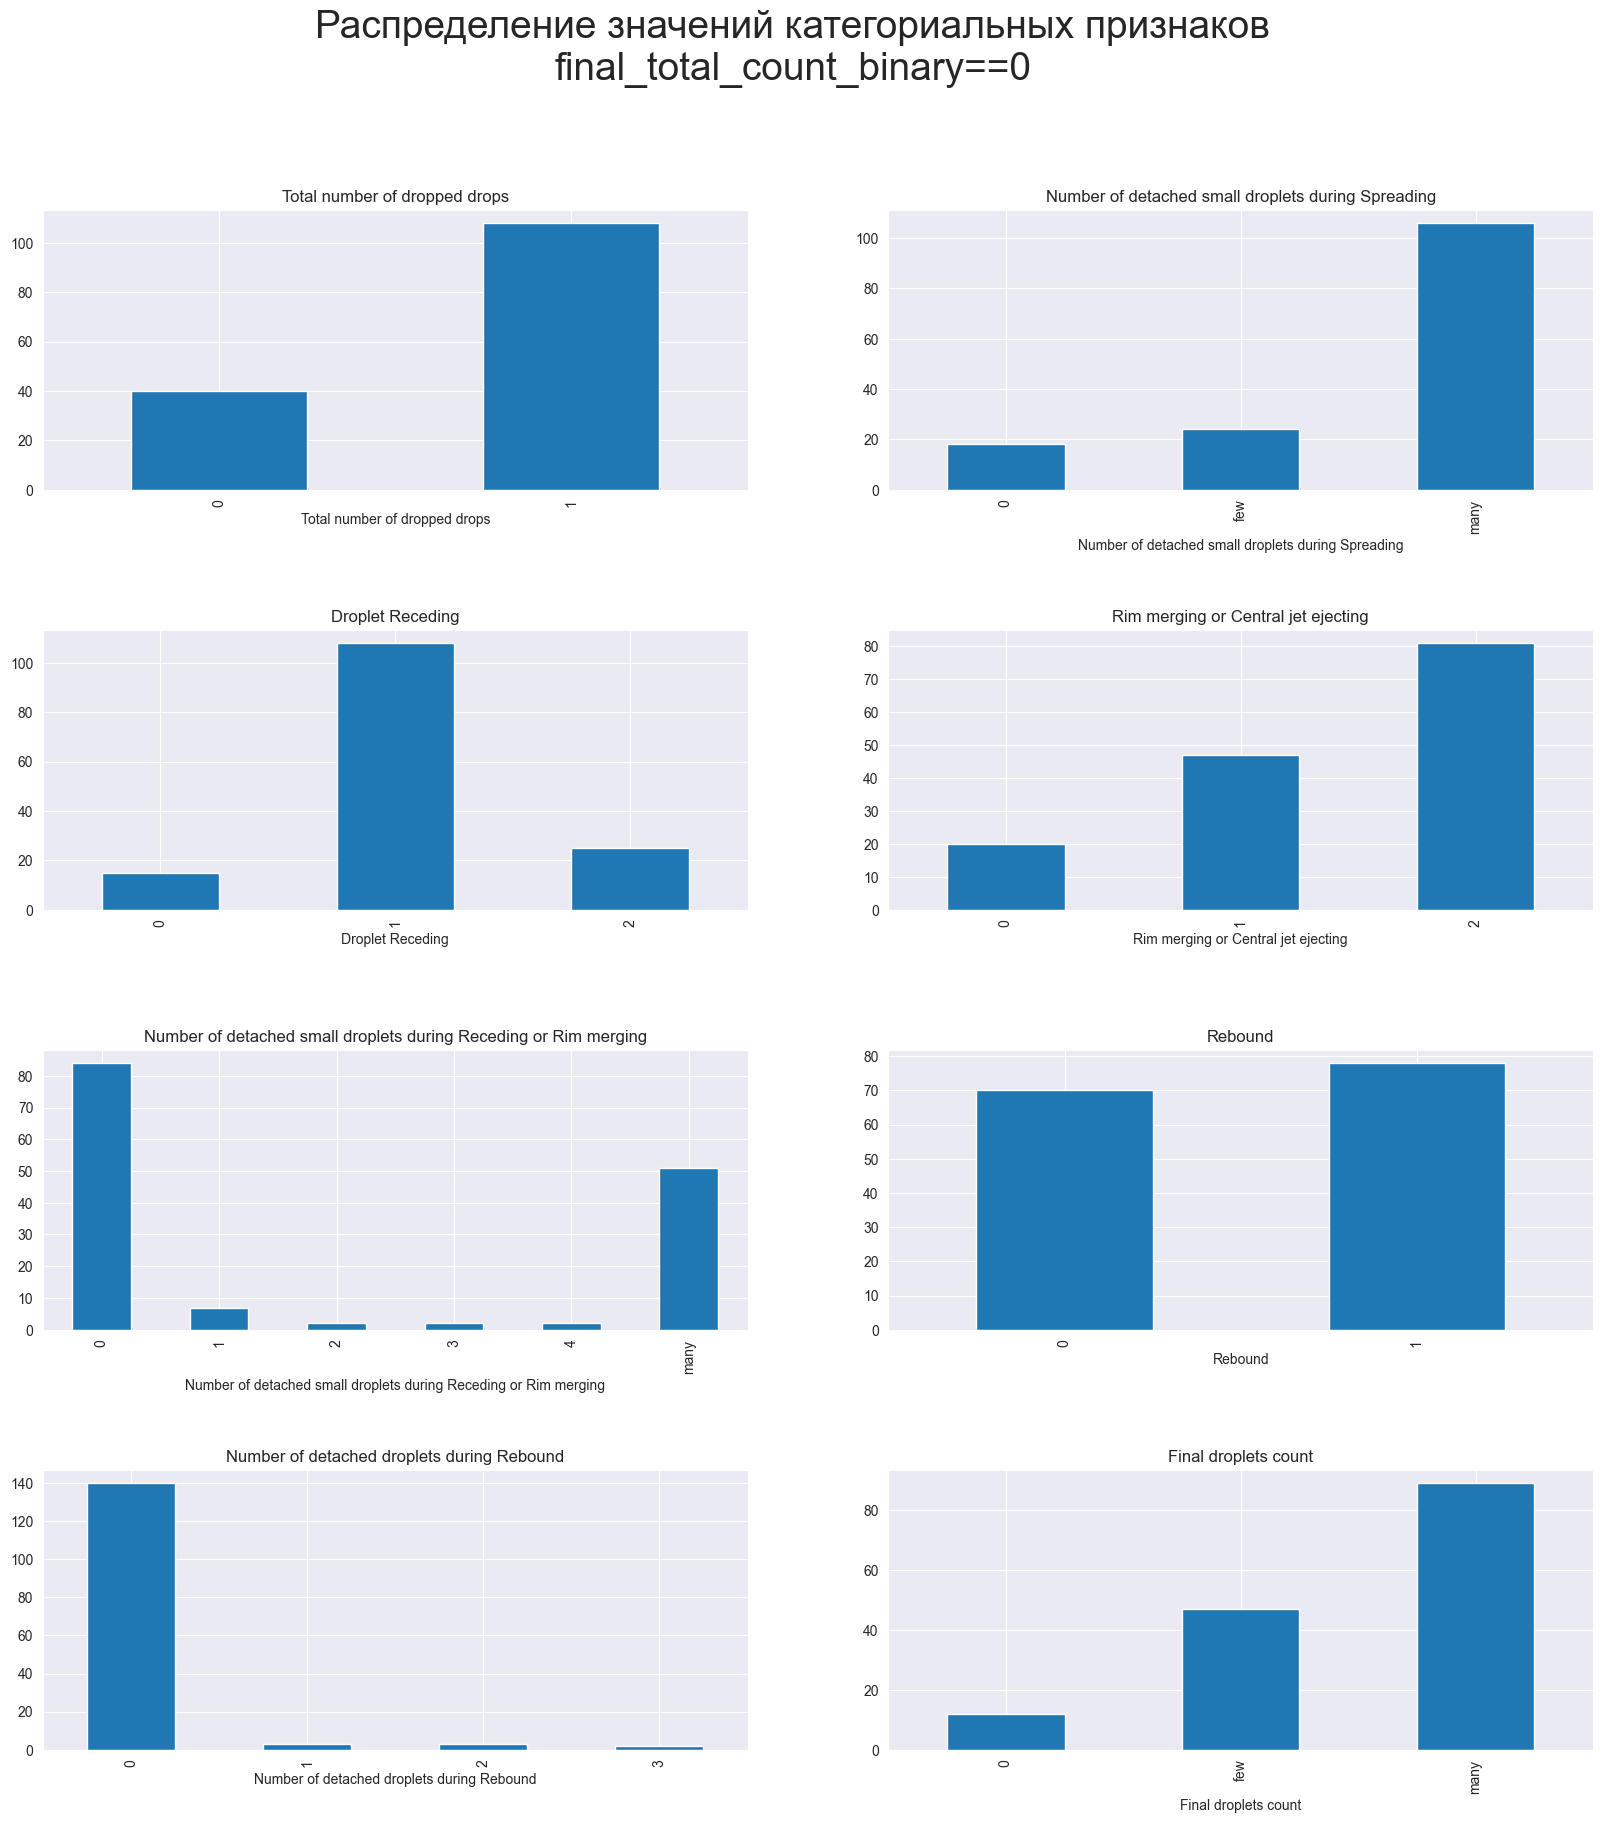

In [93]:
fig, axs = plt.subplots(4, 2, figsize=(20, 20))
plt.subplots_adjust(hspace=0.5)
fig.suptitle('Распределение значений категориальных признаков\nfinal_total_count_binary==0', fontsize=28)
for column, ax in zip(df_plot.columns, axs.ravel()):
    df_plot[column] = df_plot[column].astype(str)
    df_grouped = df_plot.groupby(by=column).size()
    df_grouped.plot.bar(ax=ax)
    ax.set_title(column)
plt.show()

## 5. Detached small droplets > 0 относим к 2 в droplet receding с переименованием в Нарушение сплошности/связности

In [94]:
df_data['Number of detached small droplets during Receding or Rim merging'].unique()

array([0, 'many', 4, 3, 2, 1], dtype=object)

In [95]:
df_data.loc[
    df_data['Number of detached small droplets during Receding or Rim merging']!=0,
    'Droplet Receding'
] = 2

## 1. Drop Receding: (2 и выше -> True) - Не торопимся делать, сначала увеличить количество в Droplet Receding == 2 исходя из пункта 5.

In [96]:
# df_data.loc[
#     df_data['Droplet Receding']==2, 
#     'Droplet Receding'
# ] = 'True'

## 6. Избавляемся от Number of detached small droplets during Receding or Rim merging, и Number of detached droplets during Rebound

In [97]:
df_data.drop(columns=['Number of detached small droplets during Receding or Rim merging',
 'Number of detached droplets during Rebound'], inplace=True)

## 7. Построить 3 Корреляции.

In [98]:
binary_columns = ['Droplet Receding', 'Rebound', 'final_total_count_binary']

### Корреляция Спирмана

In [99]:
from scipy.stats import spearmanr as spearman

In [100]:
df_data.columns

Index(['Test #', 'Total number of dropped drops',
       'Number of detached small droplets during Spreading',
       'Droplet Receding', 'Rim merging or Central jet ejecting', 'Rebound',
       'Final droplets count', 'Comments', 'horizontal_sum',
       'horizontal_sum_binary', 'final_total_count_binary'],
      dtype='object')

In [101]:
df_corr = df_data[list(set(df_data.columns) - set(['Test #', 'Comments']))].copy()
df_corr.dropna(inplace=True)

In [102]:
for column in df_corr.columns:
    df_corr[column] = df_corr[column].astype(str)
    print(column)
    print(df_corr[column].unique())
    print()

Number of detached small droplets during Spreading
['many' 'few' '0']

Droplet Receding
['0' '1' '2']

final_total_count_binary
['0' '1']

Rebound
['0' '1']

Final droplets count
['few' '1' 'many' '0']

horizontal_sum_binary
['0' '1']

Total number of dropped drops
['1' '0']

Rim merging or Central jet ejecting
['0' '1' '2']

horizontal_sum
['many' 'few' '1' '']



In [103]:
corr_spearman = spearman(df_corr)[0]

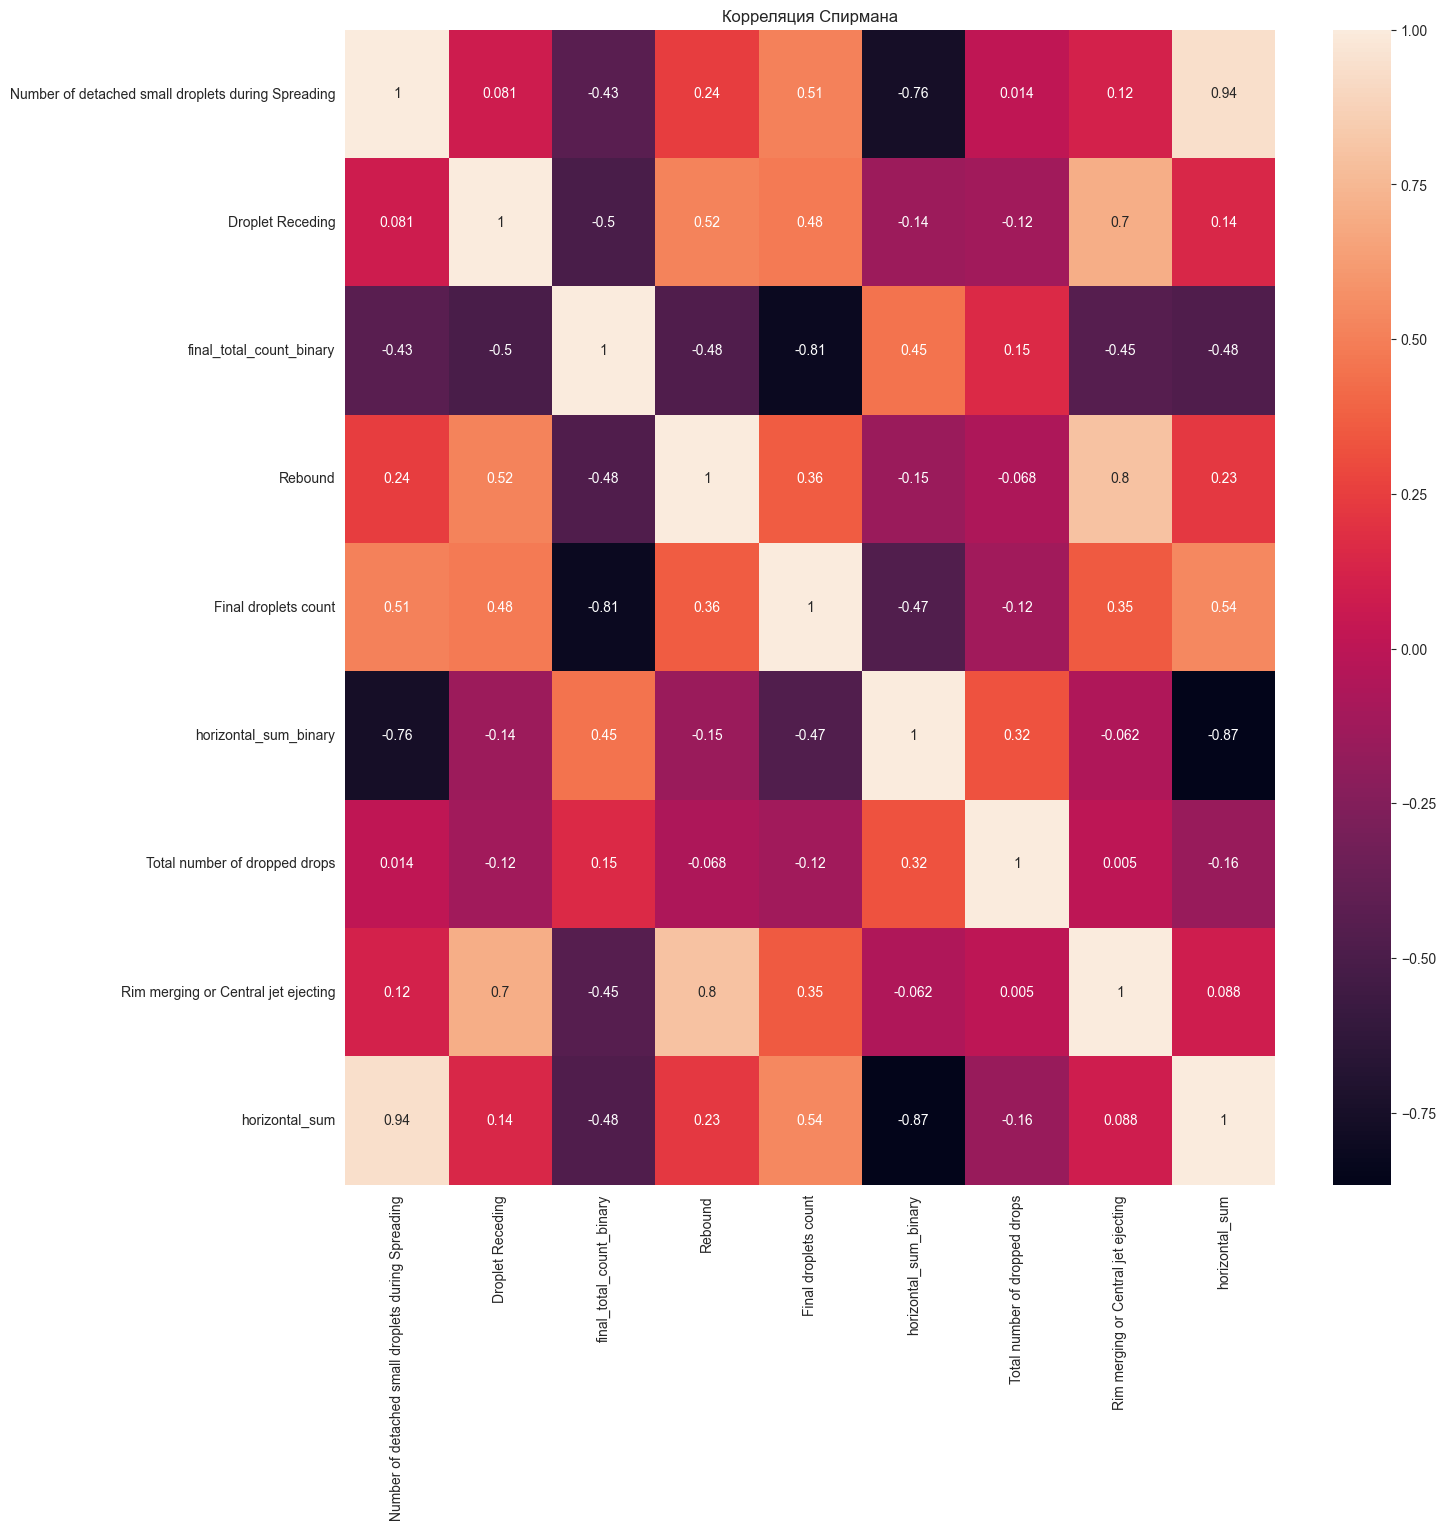

In [104]:
fig, ax = plt.subplots(figsize=(15, 15)) 
sns.heatmap(corr_spearman, annot=True, xticklabels=df_corr.columns, yticklabels=df_corr.columns, ax=ax)
plt.title('Корреляция Спирмана')
plt.show()

### Корреляция Кендалла

In [105]:
from scipy.stats import kendalltau

In [106]:
df_corr.dtypes

Number of detached small droplets during Spreading    object
Droplet Receding                                      object
final_total_count_binary                              object
Rebound                                               object
Final droplets count                                  object
horizontal_sum_binary                                 object
Total number of dropped drops                         object
Rim merging or Central jet ejecting                   object
horizontal_sum                                        object
dtype: object

In [107]:
from itertools import combinations

corrs = {}
combs = list(combinations(df_corr.columns, 2))
for comb in combs:
    corrs[comb] = kendalltau(x=df_corr[comb[0]], y=df_corr[comb[1]])[0]    

In [108]:
corrs

{('Number of detached small droplets during Spreading',
  'Droplet Receding'): 0.07408577401362504,
 ('Number of detached small droplets during Spreading',
  'final_total_count_binary'): -0.41227210653474133,
 ('Number of detached small droplets during Spreading',
  'Rebound'): 0.23187871789983275,
 ('Number of detached small droplets during Spreading',
  'Final droplets count'): 0.4795690277365963,
 ('Number of detached small droplets during Spreading',
  'horizontal_sum_binary'): -0.7297346237299875,
 ('Number of detached small droplets during Spreading',
  'Total number of dropped drops'): 0.013871829533372047,
 ('Number of detached small droplets during Spreading',
  'Rim merging or Central jet ejecting'): 0.10362464234091363,
 ('Number of detached small droplets during Spreading',
  'horizontal_sum'): 0.9066393210360887,
 ('Droplet Receding', 'final_total_count_binary'): -0.4819543869519799,
 ('Droplet Receding', 'Rebound'): 0.49402433246604865,
 ('Droplet Receding', 'Final drople

### Корреляция Мэтьюса

In [109]:
from sklearn.metrics import matthews_corrcoef

In [110]:
binary_columns

['Droplet Receding', 'Rebound', 'final_total_count_binary']

In [111]:
corrs_matthews = {}
combs = list(combinations(binary_columns, 2))
for comb in combs:
    corrs_matthews[comb] = matthews_corrcoef(df_corr[comb[0]], df_corr[comb[1]])

In [112]:
corrs_matthews

{('Droplet Receding', 'Rebound'): 0.041016780370797395,
 ('Droplet Receding', 'final_total_count_binary'): -0.007052991028565559,
 ('Rebound', 'final_total_count_binary'): -0.4785180318203095}

# Итоговые классы в разметке

In [113]:
df_data['target'] = ''

## Splashing

In [114]:
df_data['Number of detached small droplets during Spreading'].unique()

array(['many', 'few', 0], dtype=object)

In [115]:
df_data.loc[
    df_data['Number of detached small droplets during Spreading']=='many',
    'target'
] = 'Splashing'

## Spreading/receding with breaking up

In [116]:
# df_data.loc[
#     (df_data['Droplet Receding']=='True') &
#     (df_data['Number of detached small droplets during Spreading']=='few'),
#     'target'
# ] = 'Spreading/receding with breaking up'

# df_data.loc[
#     (df_data['Droplet Receding']=='True') ,
#     'target'
# ] = 'Spreading/receding with breaking up'


df_data.loc[
    (df_data['Droplet Receding']==2) |
    (df_data['Number of detached small droplets during Spreading']=='few'),
    'target'
] = 'Spreading/receding with breaking up'

## net spreading/receding

In [117]:
df_data['Number of detached small droplets during Spreading'].unique()

array(['many', 'few', 0], dtype=object)

In [118]:
df_data['Droplet Receding'].unique()

array([0, 1, 2], dtype=object)

In [119]:
df_data['Rebound'].unique()

array([0, 1], dtype=object)

In [120]:
df_data.loc[
    (df_data['Number of detached small droplets during Spreading']==0) &
    ((df_data['Droplet Receding']==0) | (df_data['Droplet Receding']==1)) &
    (df_data['Rebound']==0),
    'target'
] = 'net spreading/receding'

## central jet ejecting or rebound

In [121]:
df_data['Rebound'].unique()

array([0, 1], dtype=object)

In [122]:
df_data['Rim merging or Central jet ejecting'].unique()

array([0, 1, 2], dtype=object)

In [123]:
df_data.loc[
    (df_data['Rebound']=='True') |
    (df_data['Rim merging or Central jet ejecting']==2),
    'target'
] = 'central jet ejecting or rebound'

# Описательные статистики тартега

Распределение тартега.

In [124]:
pd.DataFrame(df_data['target'].value_counts())

,target
net spreading/receding,123
Splashing,108
central jet ejecting or rebound,105
Spreading/receding with breaking up,54


Доли final_total_count_binary в разрезе итоговых классов в разметке: Splashing, net spreading, central jet ejecting or rebound

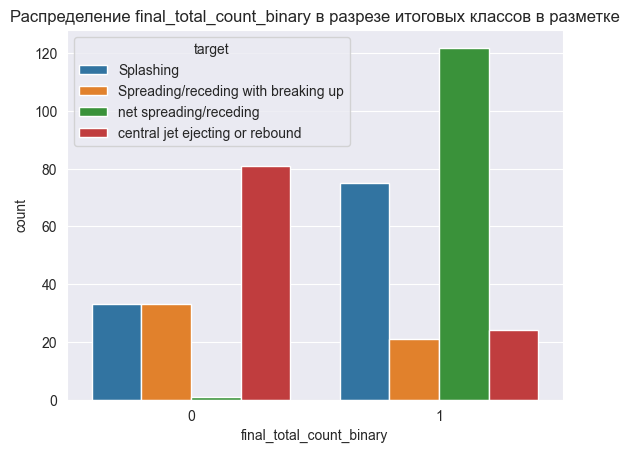

In [125]:
sns.countplot(data=df_data, x="final_total_count_binary", hue="target")
plt.title('Распределение final_total_count_binary в разрезе итоговых классов в разметке')
plt.show()

In [126]:
df_data[(df_data['target']=='net spreading/receding') & (df_data['final_total_count_binary']==0)]

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Rebound,Final droplets count,Comments,horizontal_sum,horizontal_sum_binary,final_total_count_binary,target
75,75.0,0,0,1,1,0,few,NaN,few,0,0,net spreading/receding


Доли final_total_count_binary в разрезе итоговых классов в разметке: Splashing, net spreading, central jet ejecting or rebound

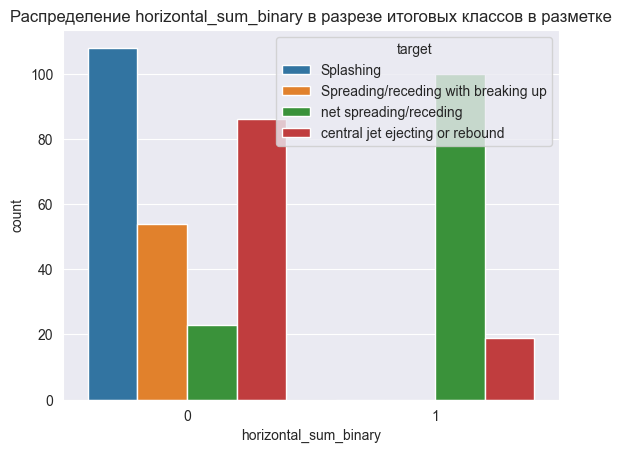

In [127]:
sns.countplot(data=df_data, x="horizontal_sum_binary", hue="target")
plt.title('Распределение horizontal_sum_binary в разрезе итоговых классов в разметке')
plt.show()

Распределение Final droplets count [1, few, many] и Number of detached small droplets during Spreading [0, few, many] ( Final droplets count == 0 не рассматриваем)

In [128]:
columns = ['Final droplets count', 'Number of detached small droplets during Spreading']

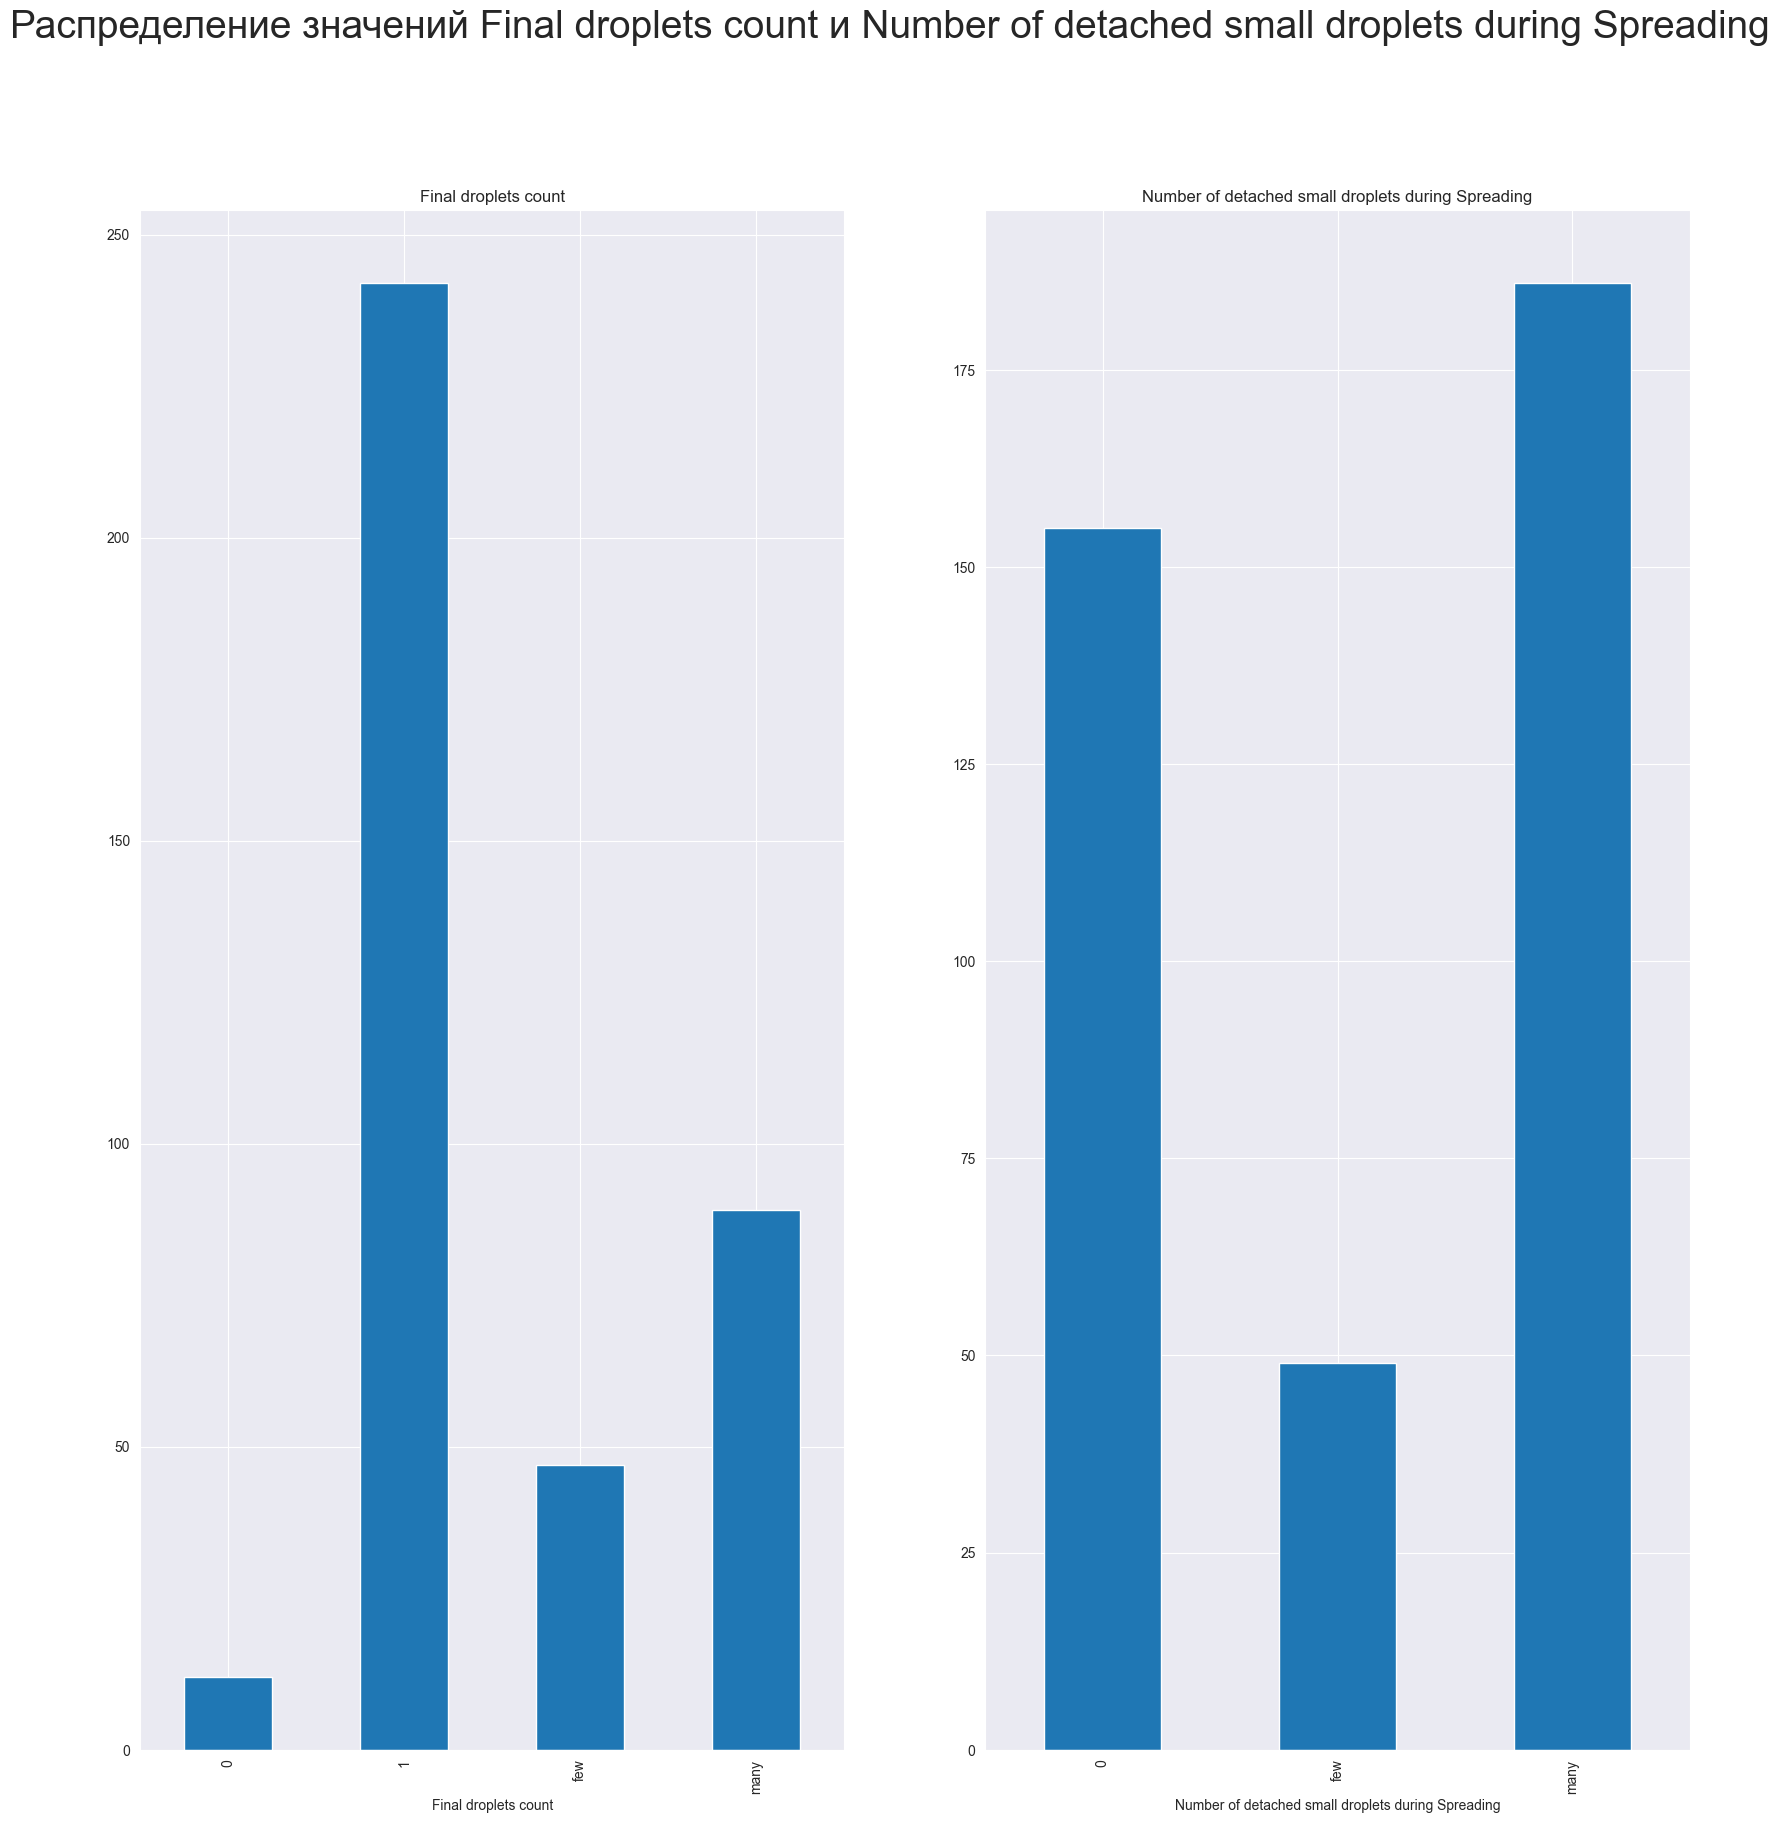

In [129]:
df_temp = df_data[columns].copy()
fig, axs = plt.subplots(1, 2, figsize=(20, 20))
plt.subplots_adjust(hspace=0.5)
fig.suptitle(f'Распределение значений {" и ".join(columns)}', fontsize=28)
for column, ax in zip(columns, axs.ravel()):
    df_temp[column] = df_temp[column].astype(str)
    df_grouped = df_temp.groupby(by=column).size()
    df_grouped.plot.bar(ax=ax)
    ax.set_title(column)
plt.show()

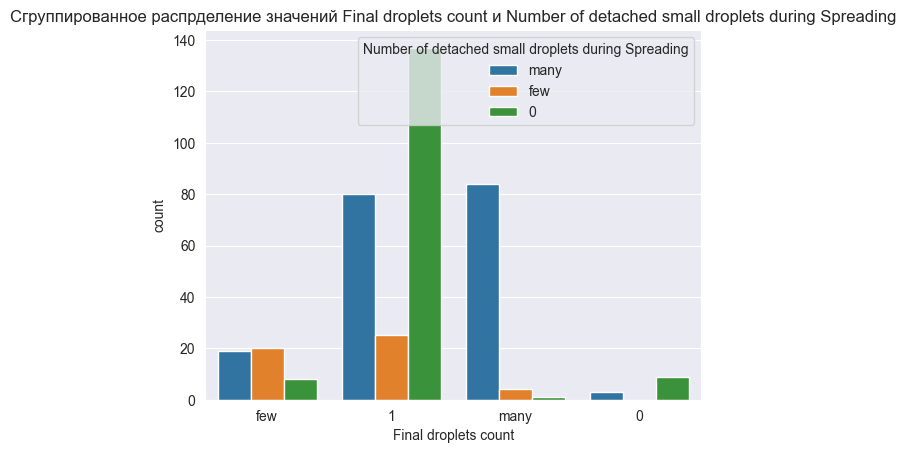

In [130]:
sns.countplot(data=df_data, x=columns[0], hue=columns[1])
plt.title(f'Сгруппированное распрделение значений {" и ".join(columns)}')
plt.show()

In [131]:
columns = ['horizontal_sum', 'Number of detached small droplets during Spreading']

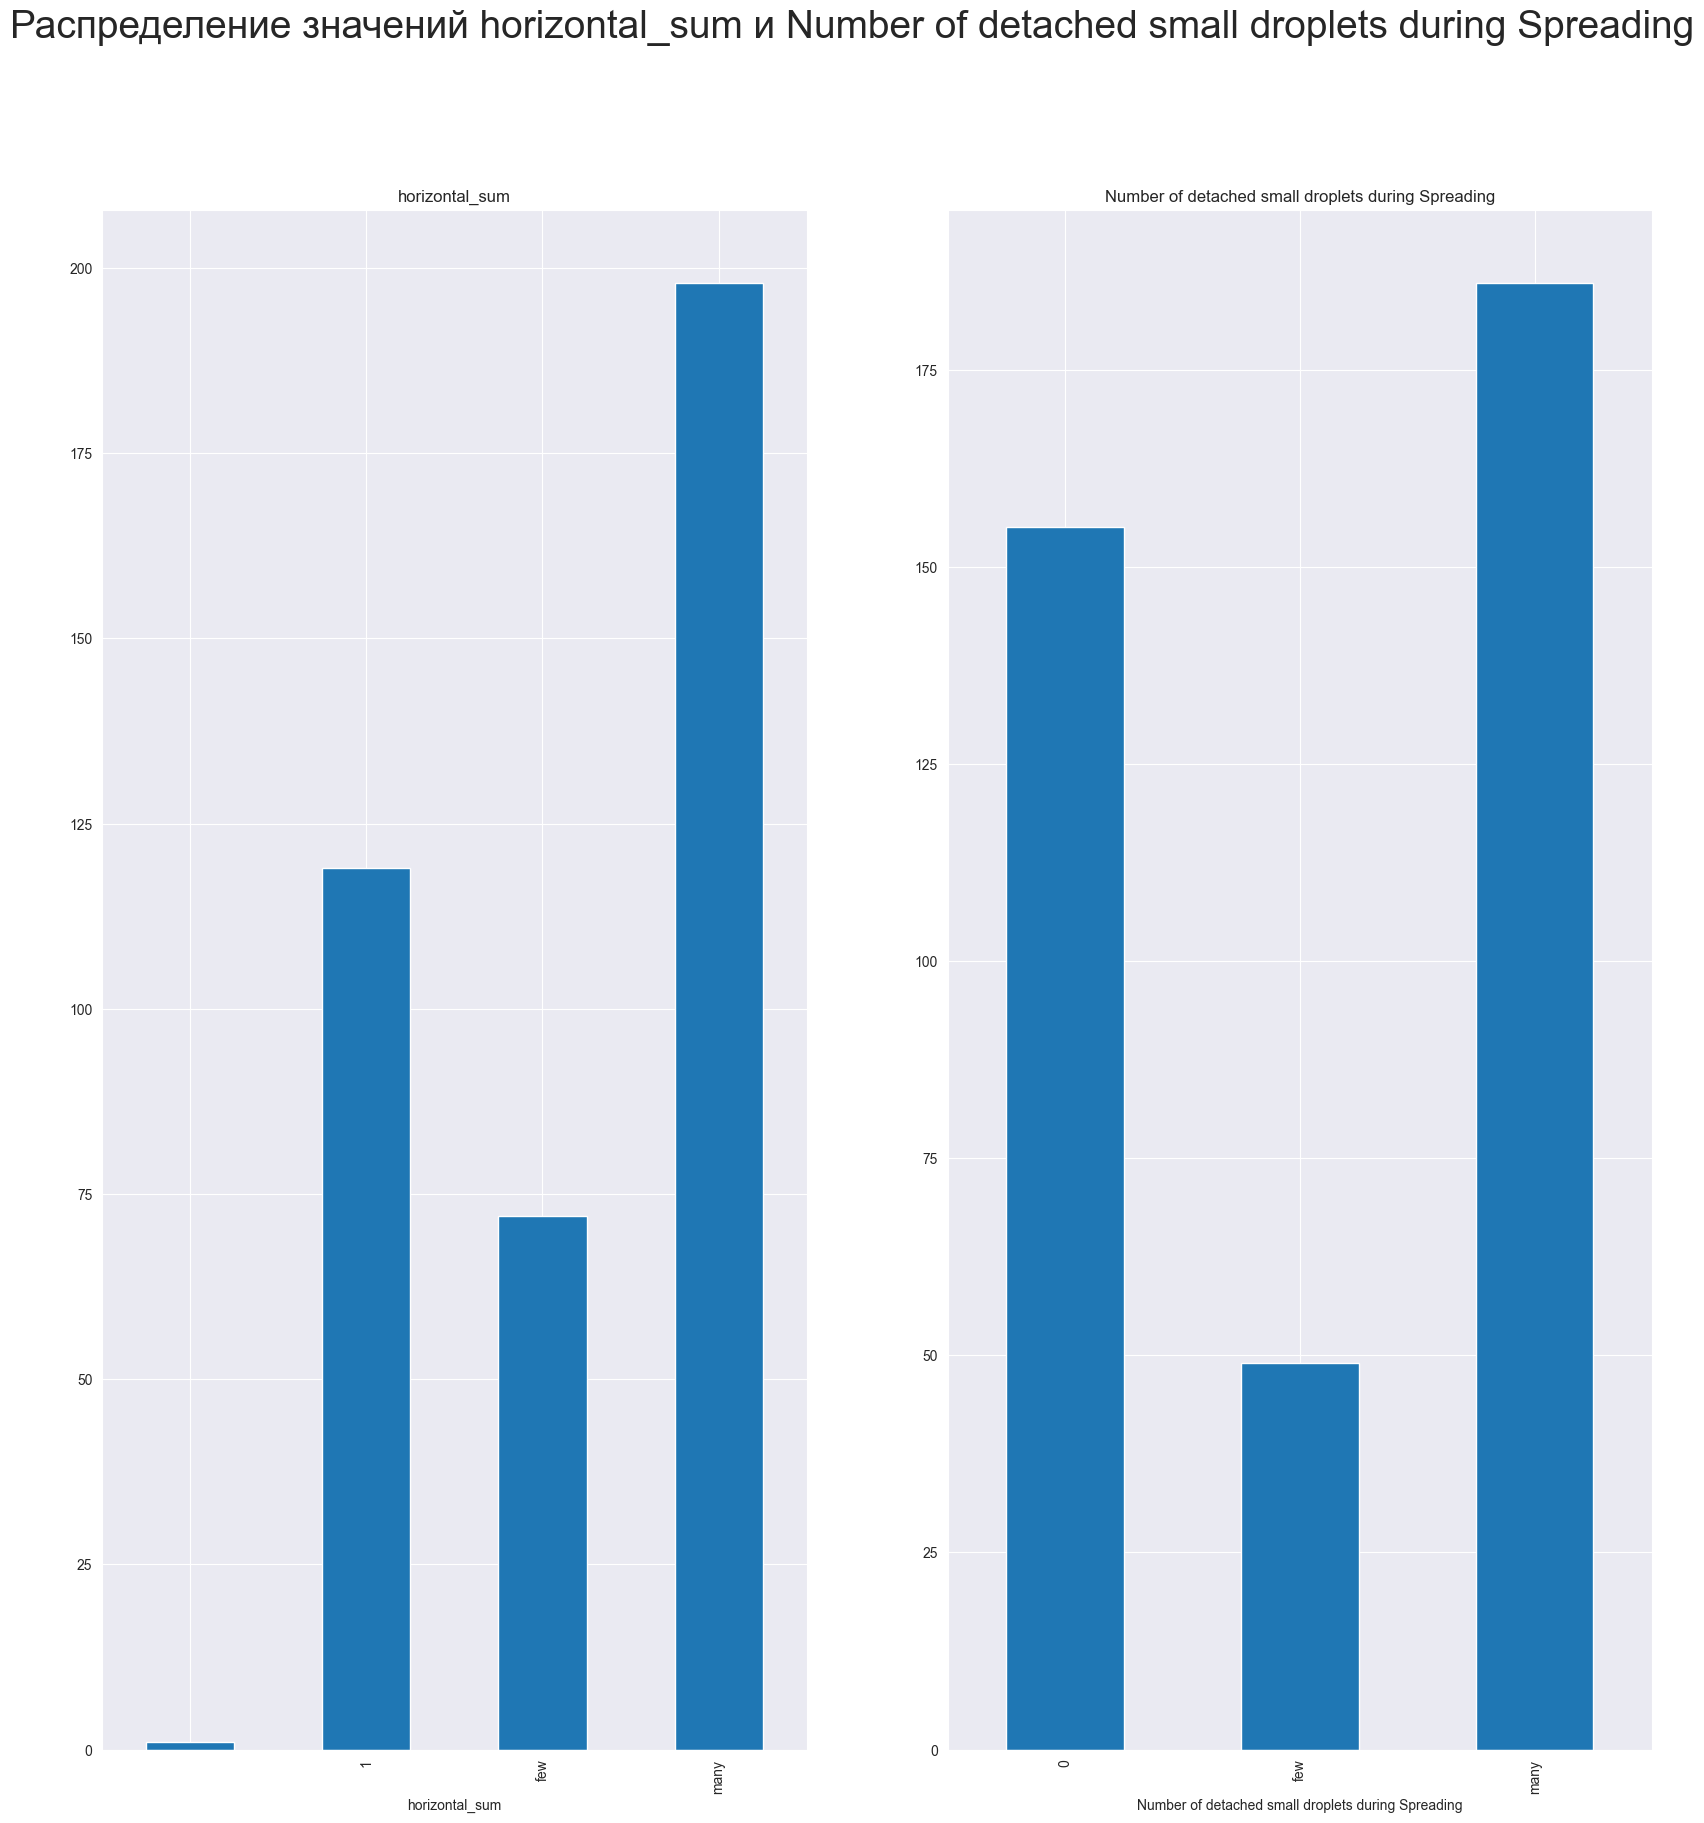

In [132]:
df_temp = df_data[columns].copy()
fig, axs = plt.subplots(1, 2, figsize=(20, 20))
plt.subplots_adjust(hspace=0.5)
fig.suptitle(f'Распределение значений {" и ".join(columns)}', fontsize=28)
for column, ax in zip(columns, axs.ravel()):
    df_temp[column] = df_temp[column].astype(str)
    df_grouped = df_temp.groupby(by=column).size()
    df_grouped.plot.bar(ax=ax)
    ax.set_title(column)
plt.show()

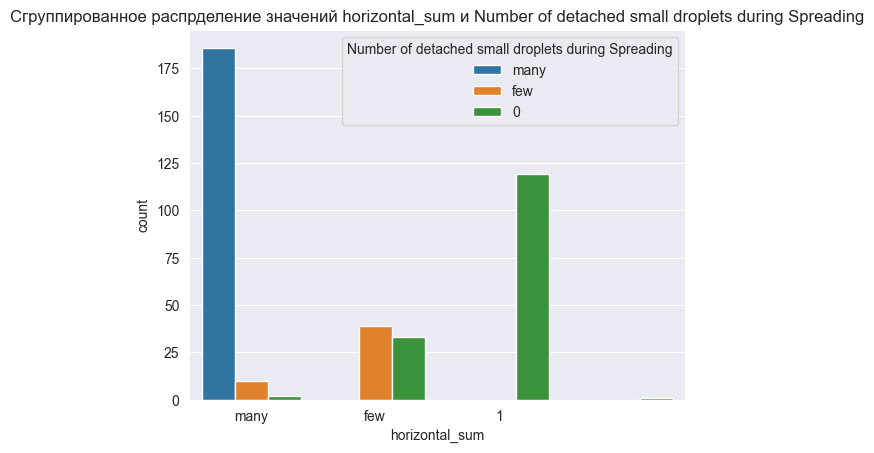

In [133]:
sns.countplot(data=df_data, x=columns[0], hue=columns[1])
plt.title(f'Сгруппированное распрделение значений {" и ".join(columns)}')
plt.show()

 Распределение, но между Final droplets count [0, 1, few, many] и Droplet Receding (скорректированное); Rim merging or Central jet ejecting; Rebound.

In [134]:
columns = ['Final droplets count', 'Droplet Receding', 'Rim merging or Central jet ejecting', 'Rebound']

In [135]:
combs = list(combinations(columns, 2))
print(len(combs))

6


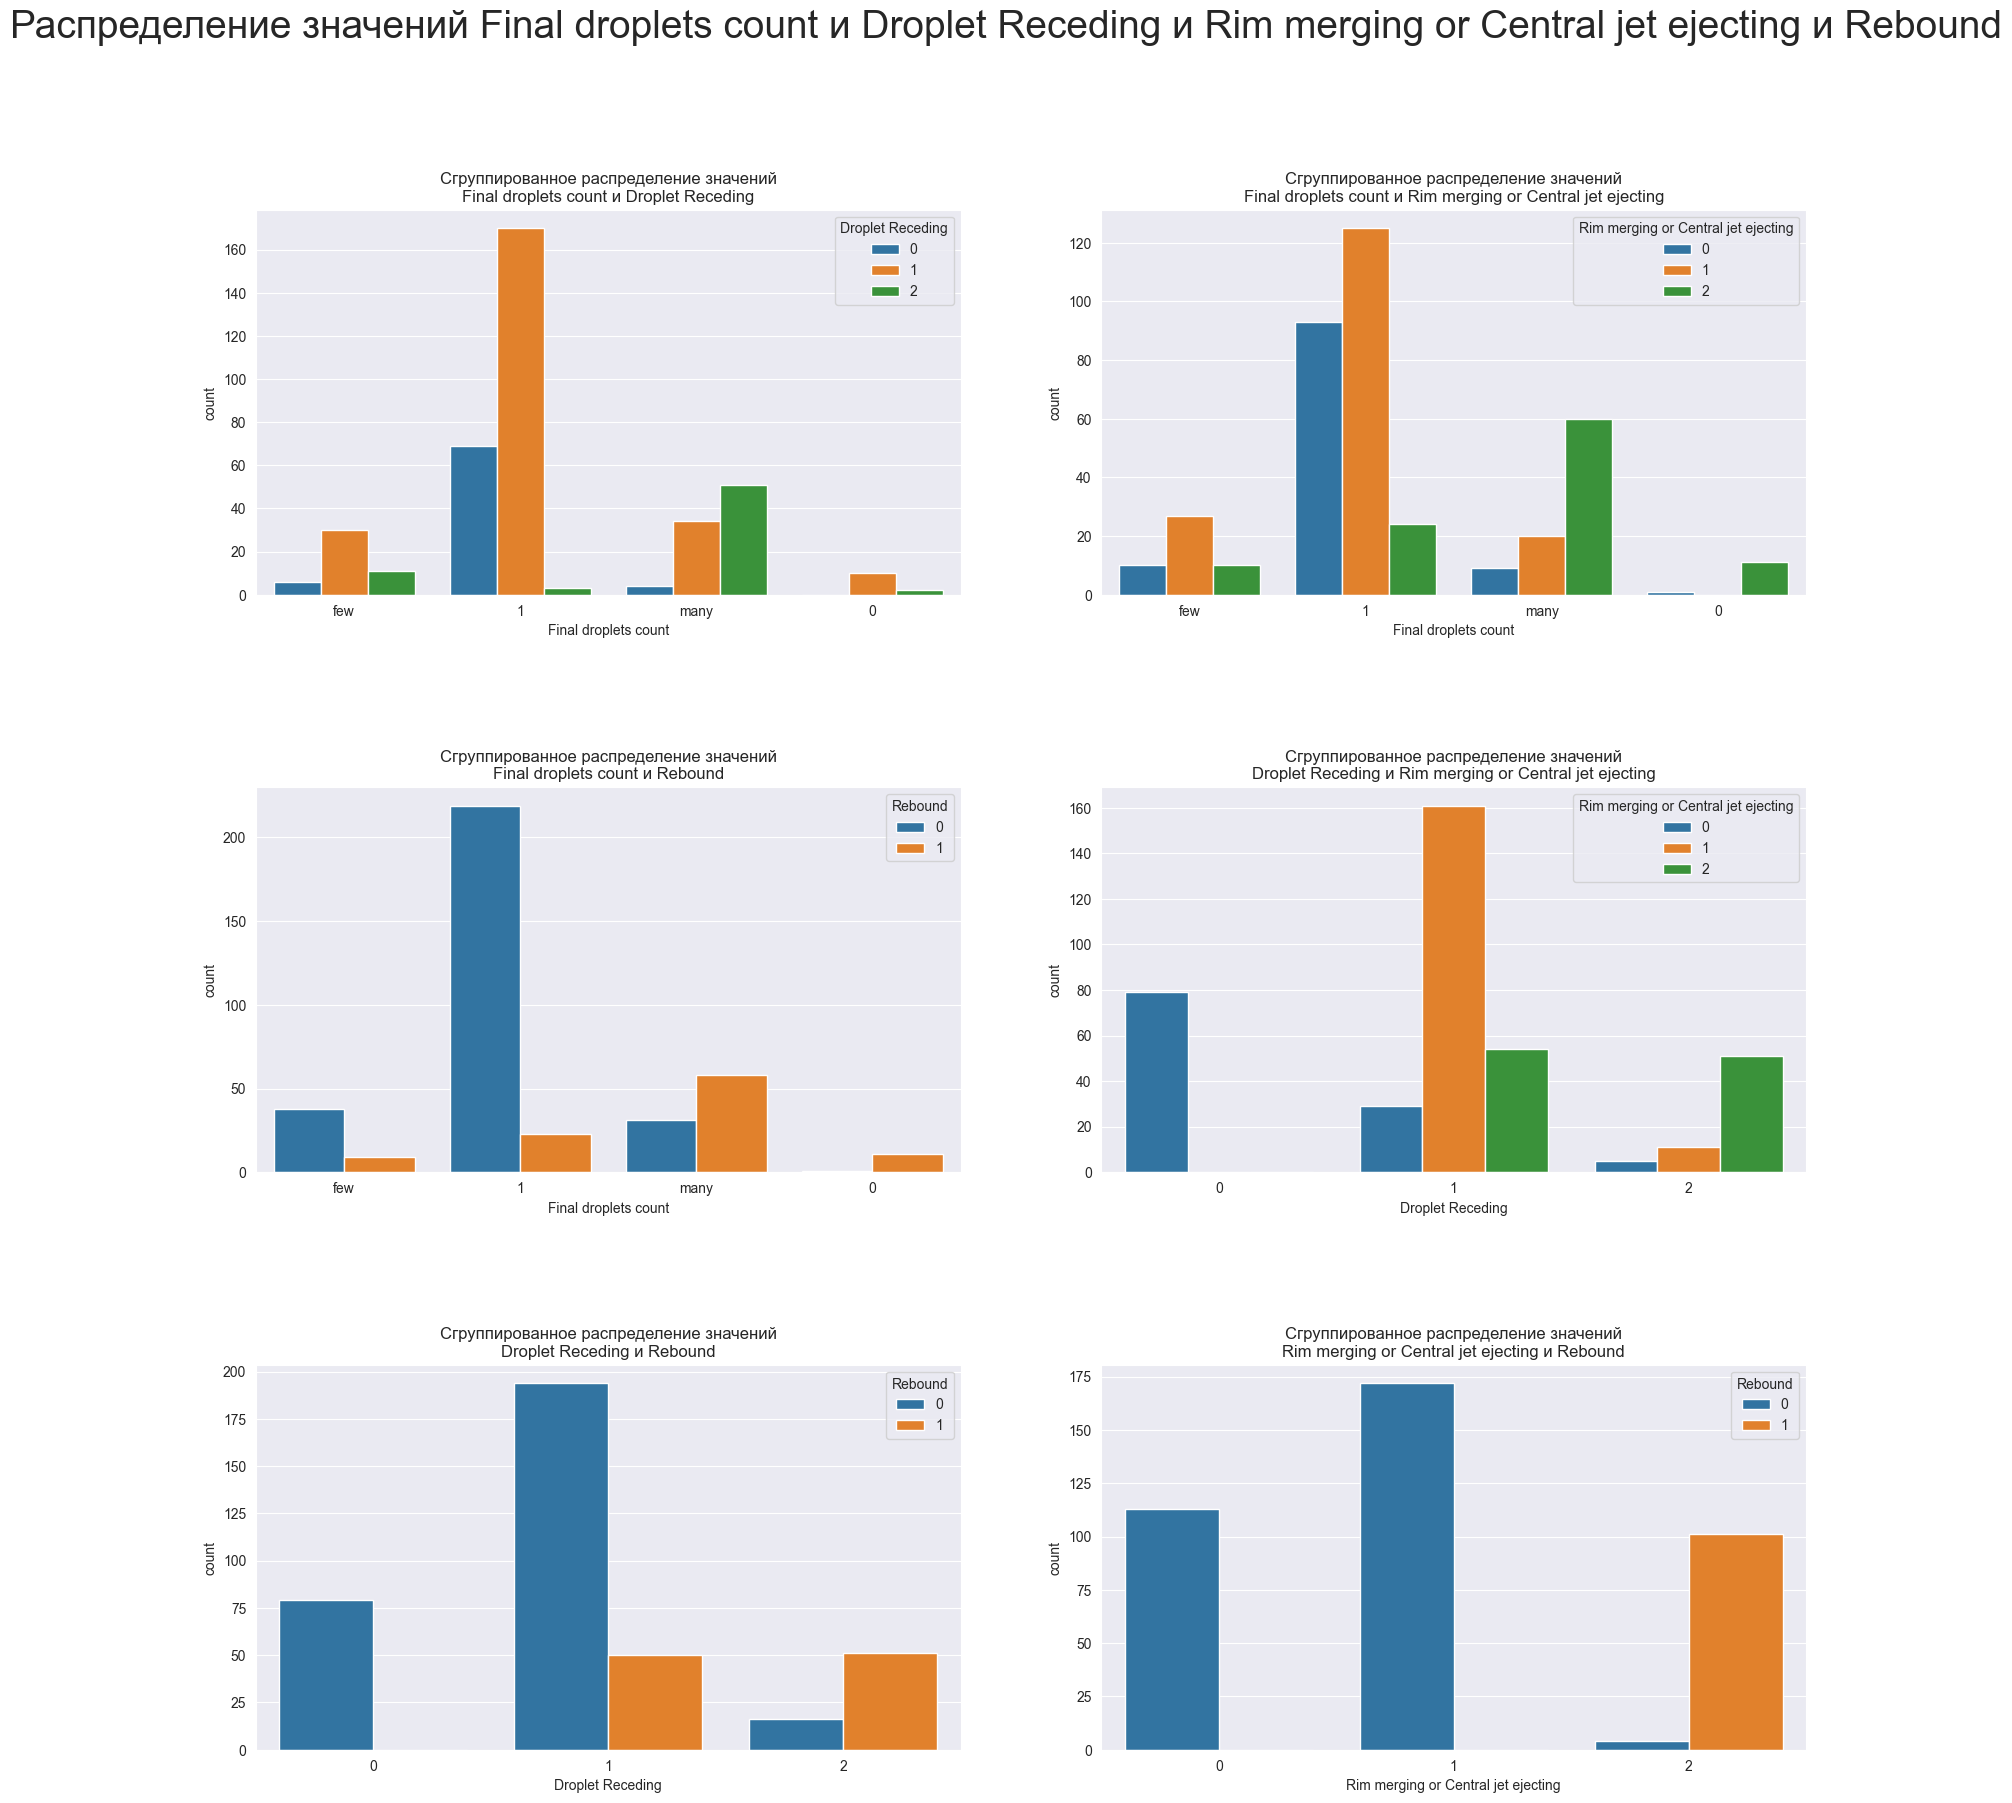

In [136]:
fig, axs = plt.subplots(3, 2, figsize=(20, 20))
plt.subplots_adjust(hspace=0.5)
fig.suptitle(f'Распределение значений {" и ".join(columns)}', fontsize=28)
for comb, ax in zip(combs, axs.ravel()):
    sns.countplot(data=df_data, x=comb[0], hue=comb[1], ax=ax)
    ax.set_title(f'Сгруппированное распределение значений\n{" и ".join(comb)}')
plt.show()